# Stress Testing and Scenario Analysis
**Docker image**: `ml4t`

**Purpose**: Replay historical crises, apply user-defined scenario shocks, and
run Monte Carlo simulations on a panel of canonical ETF allocations to quantify
tail behaviour and contrast portfolio robustness.

**Learning objectives**:
1. Reproduce portfolio losses during the 2008 GFC, 2020 COVID, and 2022 Fed
   tightening windows for four reference allocations (60/40, All Weather,
   Aggressive Equity, Defensive).
2. Define correlated-shock scenarios and apply them via a weighted sum.
3. Run a Student-t Monte Carlo with kurtosis-adjusted degrees of freedom and
   read 95%/99% VaR plus 95% CVaR over a 20-day horizon.
4. Compare regime-conditional return statistics (Bull / Calm / High Vol / Bear).

**Book reference**: §19.6 (Stress Testing and Scenario Analysis); also cited
from §19.1 and §19.2.

**Prerequisites**: Portfolio returns and drawdown metrics from `01_var_cvar`,
Chapter 17 portfolio construction, and comfort treating stress tables as
decision support rather than point forecasts.

**Data**: Canonical ETF panel via `data.load_etfs()` for SPY, EFA, EEM, AGG,
TLT, GLD, VNQ; window 2007-01-01 to 2024-01-01.

## Setup

In [1]:
"""Stress Testing and Scenario Analysis — replay historical crises, design hypothetical scenarios, and run Monte Carlo simulations."""

import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots
from scipy import stats

from data import load_etfs
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0
SEED = 42

In [3]:
set_global_seeds(SEED)

`max_drawdown` returns the most negative point of the equity curve
relative to its running peak (a percentage, not an absolute wealth
difference). It is the single drawdown definition used throughout the
stress-period replay, sensitivity analysis, and regime tables below.

In [4]:
def max_drawdown(returns_array: np.ndarray) -> float:
    """Compute percentage maximum drawdown from a 1D returns series."""

    equity_curve = np.cumprod(1 + np.asarray(returns_array, dtype=float))
    running_peak = np.maximum.accumulate(equity_curve)
    drawdown = equity_curve / running_peak - 1
    return float(drawdown.min())

## 1. Historical Data

In [5]:
# Load diversified portfolio from canonical ETF universe
SYMBOLS = {
    "SPY": "US Equity",
    "EFA": "Int'l Equity",
    "EEM": "EM Equity",
    "AGG": "US Bonds",
    "TLT": "Long Treasury",
    "GLD": "Gold",
    "VNQ": "Real Estate",
}

START_DATE = "2007-01-01"  # Include 2008 crisis
END_DATE = "2024-01-01"

etf_data = load_etfs()

# Filter to symbols and date range
etf_filtered = (
    etf_data.filter(pl.col("symbol").is_in(list(SYMBOLS.keys())))
    .filter(pl.col("timestamp") >= pl.lit(START_DATE).str.to_datetime())
    .filter(pl.col("timestamp") <= pl.lit(END_DATE).str.to_datetime())
    .sort(["symbol", "timestamp"])
)

# Pivot to wide format
close_prices = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .to_pandas()
    .set_index("timestamp")
)
close_prices.index = pd.to_datetime(close_prices.index)
close_prices = close_prices.ffill().dropna()

returns = close_prices.pct_change().dropna()

print(f"Loaded {len(returns):,} daily returns from canonical data")

Loaded 4,277 daily returns from canonical data


The return panel spans the crises we want to replay, so it gives the notebook one consistent
base dataset for historical stress, hypothetical shocks, and simulated tail scenarios.

## 2. Historical Crisis Periods

Define major market stress events for analysis.

In [6]:
# Major historical stress periods
STRESS_PERIODS = {
    "2008 Global Financial Crisis": ("2008-09-01", "2009-03-09"),
    "2010 Flash Crash": ("2010-05-06", "2010-05-07"),
    "2011 US Debt Downgrade": ("2011-08-04", "2011-08-08"),
    "2015 China Devaluation": ("2015-08-18", "2015-08-25"),
    "2018 Q4 Selloff": ("2018-10-01", "2018-12-24"),
    "2020 COVID Crash": ("2020-02-19", "2020-03-23"),
    "2022 Fed Tightening": ("2022-01-03", "2022-10-12"),
}

This helper turns a date window into portfolio-level stress statistics so each crisis can be
compared on the same basis.

In [7]:
def analyze_stress_period(
    returns: pd.DataFrame,
    start_date: str,
    end_date: str,
    portfolio_weights: dict[str, float] | None = None,
) -> dict:
    """Analyze portfolio performance during a stress period."""

    period_returns = returns.loc[start_date:end_date]
    if len(period_returns) == 0:
        return None
    if portfolio_weights is None:
        portfolio_weights = {s: 1 / len(returns.columns) for s in returns.columns}
    weights = pd.Series(portfolio_weights)
    portfolio_ret = (period_returns * weights).sum(axis=1)
    cum_return = (1 + portfolio_ret).prod() - 1
    max_dd = max_drawdown(portfolio_ret.values)
    asset_returns = {asset: (1 + period_returns[asset]).prod() - 1 for asset in returns.columns}
    return {
        "cum_return": cum_return,
        "max_drawdown": max_dd,
        "days": len(period_returns),
        "worst_day": portfolio_ret.min(),
        "best_day": portfolio_ret.max(),
        "volatility": portfolio_ret.std() * np.sqrt(252),
        "asset_returns": asset_returns,
    }

In [8]:
# Analyze all stress periods with equal-weight portfolio
print("Historical Stress Period Analysis")
print("=" * 70)

stress_results = {}
for name, (start, end) in STRESS_PERIODS.items():
    result = analyze_stress_period(returns, start, end)
    if result:
        stress_results[name] = result
        print(f"\n{name} ({start} to {end})")
        print(f"  Duration:     {result['days']} days")
        print(f"  Portfolio:    {result['cum_return'] * 100:+.2f}%")
        print(f"  Max Drawdown: {result['max_drawdown'] * 100:.2f}%")
        print(f"  Worst Day:    {result['worst_day'] * 100:.2f}%")
        print(f"  Volatility:   {result['volatility'] * 100:.1f}% (ann.)")

Historical Stress Period Analysis

2008 Global Financial Crisis (2008-09-01 to 2009-03-09)
  Duration:     130 days
  Portfolio:    -27.69%
  Max Drawdown: -31.14%
  Worst Day:    -6.68%
  Volatility:   42.9% (ann.)

2010 Flash Crash (2010-05-06 to 2010-05-07)
  Duration:     2 days
  Portfolio:    -2.07%
  Max Drawdown: -0.68%
  Worst Day:    -1.40%
  Volatility:   8.1% (ann.)

2011 US Debt Downgrade (2011-08-04 to 2011-08-08)
  Duration:     3 days
  Portfolio:    -6.66%
  Max Drawdown: -4.10%
  Worst Day:    -3.50%
  Volatility:   23.4% (ann.)

2015 China Devaluation (2015-08-18 to 2015-08-25)
  Duration:     6 days
  Portfolio:    -5.44%
  Max Drawdown: -5.05%
  Worst Day:    -2.47%
  Volatility:   13.6% (ann.)

2018 Q4 Selloff (2018-10-01 to 2018-12-24)
  Duration:     59 days
  Portfolio:    -6.21%
  Max Drawdown: -6.03%
  Worst Day:    -1.40%
  Volatility:   9.7% (ann.)

2020 COVID Crash (2020-02-19 to 2020-03-23)
  Duration:     24 days
  Portfolio:    -19.69%
  Max Drawdown: -

Historical replay shows how a diversified portfolio behaves when correlations compress and
defensive sleeves are tested alongside equities. The next chart makes the cross-asset damage
pattern easier to compare across crises.

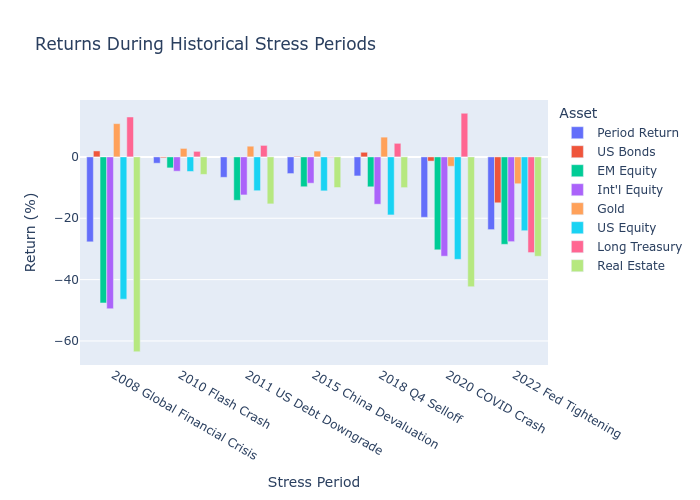

In [9]:
# Visualize stress period returns
stress_df = pd.DataFrame(
    {
        name: {
            **{"Period Return": result["cum_return"] * 100},
            **{SYMBOLS[k]: v * 100 for k, v in result["asset_returns"].items()},
        }
        for name, result in stress_results.items()
    }
).T

fig = px.bar(
    stress_df.reset_index().melt(id_vars="index", var_name="Asset", value_name="Return"),
    x="index",
    y="Return",
    color="Asset",
    barmode="group",
    title="Returns During Historical Stress Periods",
)
fig.update_layout(
    xaxis_title="Stress Period",
    yaxis_title="Return (%)",
    height=500,
)
fig.show()

The grouped bars make an important point for governance: diversification helps, but the mix of
winners and losers changes materially by crisis type, so one historical event is not enough.

## 3. Portfolio Comparison Under Stress

Compare different portfolio allocations during stress periods.

In [10]:
# Define portfolio allocations
PORTFOLIOS = {
    "60/40 Stocks/Bonds": {"SPY": 0.60, "AGG": 0.40},
    "All Weather": {"SPY": 0.30, "TLT": 0.40, "GLD": 0.15, "VNQ": 0.15},
    "Aggressive Equity": {"SPY": 0.60, "EFA": 0.20, "EEM": 0.20},
    "Defensive": {"AGG": 0.40, "TLT": 0.30, "GLD": 0.20, "SPY": 0.10},
}


def compare_portfolios_stress(
    returns: pd.DataFrame,
    portfolios: dict[str, dict[str, float]],
    stress_periods: dict[str, tuple],
) -> pd.DataFrame:
    """Compare portfolio performance across stress periods."""
    results = []

    for period_name, (start, end) in stress_periods.items():
        for port_name, weights in portfolios.items():
            result = analyze_stress_period(returns, start, end, weights)
            if result:
                results.append(
                    {
                        "Period": period_name,
                        "Portfolio": port_name,
                        "Return": result["cum_return"] * 100,
                        "Max DD": result["max_drawdown"] * 100,
                        "Worst Day": result["worst_day"] * 100,
                    }
                )

    return pd.DataFrame(results)

In [11]:
comparison_df = compare_portfolios_stress(returns, PORTFOLIOS, STRESS_PERIODS)

# Pivot for display
pivot_return = comparison_df.pivot(index="Period", columns="Portfolio", values="Return")
print("\nPortfolio Returns During Stress (%)")
print("=" * 70)
print(pivot_return.round(2).to_markdown())


Portfolio Returns During Stress (%)
| Period                       |   60/40 Stocks/Bonds |   Aggressive Equity |   All Weather |   Defensive |
|:-----------------------------|---------------------:|--------------------:|--------------:|------------:|
| 2008 Global Financial Crisis |               -29.2  |              -46.72 |        -19.45 |        2.19 |
| 2010 Flash Crash             |                -2.98 |               -4.5  |         -1.16 |        0.5  |
| 2011 US Debt Downgrade       |                -6.72 |              -11.92 |         -3.71 |        0.67 |
| 2015 China Devaluation       |                -6.69 |              -10.3  |         -4.71 |       -0.75 |
| 2018 Q4 Selloff              |               -11.17 |              -16.41 |         -4.86 |        1.14 |
| 2020 COVID Crash             |               -21.5  |              -32.53 |        -12.97 |       -0.61 |
| 2022 Fed Tightening          |               -20.14 |              -25.52 |        -25.56 |      

Comparing allocations across the same crisis windows highlights the tradeoff between protection
and participation. Defensive mixes lose less in equity crashes, but they are not uniformly best
once the stress comes from rates instead of growth.

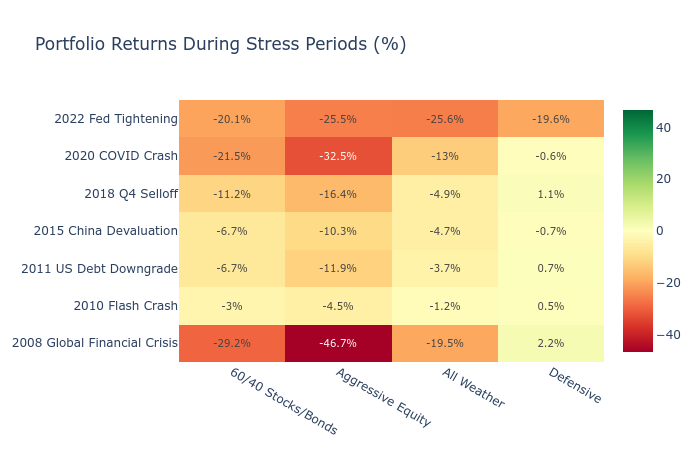

In [12]:
# Heatmap of stress performance
fig = go.Figure(
    data=go.Heatmap(
        z=pivot_return.values,
        x=pivot_return.columns,
        y=pivot_return.index,
        colorscale="RdYlGn",
        zmid=0,
        text=np.round(pivot_return.values, 1),
        texttemplate="%{text}%",
        textfont={"size": 10},
    )
)

fig.update_layout(
    title="Portfolio Returns During Stress Periods (%)",
    height=450,
)
fig.show()

The heatmap is the compact committee view: it shows immediately which portfolios are robust
across several historical episodes and which ones rely on one specific crisis pattern.

## 4. Hypothetical Scenario Analysis

Create user-defined stress scenarios to test portfolio resilience.

Hypothetical scenarios let us test exposures that are plausible but not identical to any one
historical window. We start by defining a simple scenario object.

In [13]:
@dataclass
class StressScenario:
    """User-defined stress scenario."""

    name: str
    shocks: dict[str, float]  # Asset -> shock magnitude
    description: str = ""

In [14]:
# Define hypothetical scenarios
SCENARIOS = [
    StressScenario(
        name="Equity Crash (-30%)",
        shocks={
            "SPY": -0.30,
            "EFA": -0.35,
            "EEM": -0.40,
            "VNQ": -0.25,
            "AGG": 0.02,
            "TLT": 0.10,
            "GLD": 0.05,
        },
        description="Major equity selloff, flight to quality",
    ),
    StressScenario(
        name="Rising Rates (+200bps)",
        shocks={
            "SPY": -0.10,
            "EFA": -0.08,
            "EEM": -0.15,
            "VNQ": -0.20,
            "AGG": -0.10,
            "TLT": -0.25,
            "GLD": -0.05,
        },
        description="Fed tightening, bond selloff",
    ),
]

In [15]:
SCENARIOS.append(
    StressScenario(
        name="Stagflation",
        shocks={
            "SPY": -0.20,
            "EFA": -0.25,
            "EEM": -0.30,
            "VNQ": -0.15,
            "AGG": -0.05,
            "TLT": -0.10,
            "GLD": 0.20,
        },
        description="High inflation + recession",
    ),
)

In [16]:
SCENARIOS.extend(
    [
        StressScenario(
            name="Deflation Crisis",
            shocks={
                "SPY": -0.25,
                "EFA": -0.30,
                "EEM": -0.35,
                "VNQ": -0.30,
                "AGG": 0.05,
                "TLT": 0.20,
                "GLD": -0.10,
            },
            description="Severe deflation, long bonds rally",
        ),
        StressScenario(
            name="EM Crisis",
            shocks={
                "SPY": -0.10,
                "EFA": -0.15,
                "EEM": -0.40,
                "VNQ": -0.05,
                "AGG": 0.02,
                "TLT": 0.05,
                "GLD": 0.10,
            },
            description="Emerging market contagion",
        ),
    ]
)

Applying a scenario is just a weighted sum of the asset shocks. Keeping that logic separate
makes the scenario table easier to audit and reuse.

In [17]:
def apply_scenario(
    portfolio_weights: dict[str, float],
    scenario: StressScenario,
) -> dict:
    """Calculate portfolio impact from a stress scenario."""
    portfolio_shock = sum(
        portfolio_weights.get(asset, 0) * shock for asset, shock in scenario.shocks.items()
    )

    return {
        "scenario": scenario.name,
        "portfolio_shock": portfolio_shock,
        "description": scenario.description,
    }

In [18]:
# Apply scenarios to all portfolios
print("Hypothetical Scenario Analysis")
print("=" * 70)

scenario_results = []
for scenario in SCENARIOS:
    print(f"\n{scenario.name}: {scenario.description}")
    for port_name, weights in PORTFOLIOS.items():
        result = apply_scenario(weights, scenario)
        scenario_results.append(
            {
                "Scenario": scenario.name,
                "Portfolio": port_name,
                "Impact": result["portfolio_shock"] * 100,
            }
        )
        print(f"  {port_name}: {result['portfolio_shock'] * 100:+.1f}%")

scenario_df = pd.DataFrame(scenario_results)

Hypothetical Scenario Analysis

Equity Crash (-30%): Major equity selloff, flight to quality
  60/40 Stocks/Bonds: -17.2%
  All Weather: -8.0%
  Aggressive Equity: -33.0%
  Defensive: +1.8%

Rising Rates (+200bps): Fed tightening, bond selloff
  60/40 Stocks/Bonds: -10.0%
  All Weather: -16.8%
  Aggressive Equity: -10.6%
  Defensive: -13.5%

Stagflation: High inflation + recession
  60/40 Stocks/Bonds: -14.0%
  All Weather: -9.2%
  Aggressive Equity: -23.0%
  Defensive: -3.0%

Deflation Crisis: Severe deflation, long bonds rally
  60/40 Stocks/Bonds: -13.0%
  All Weather: -5.5%
  Aggressive Equity: -28.0%
  Defensive: +3.5%

EM Crisis: Emerging market contagion
  60/40 Stocks/Bonds: -5.2%
  All Weather: -0.2%
  Aggressive Equity: -17.0%
  Defensive: +3.3%


The scenario table is the fastest way to test whether a portfolio is accidentally concentrated
in one macro view, such as falling rates or benign inflation.

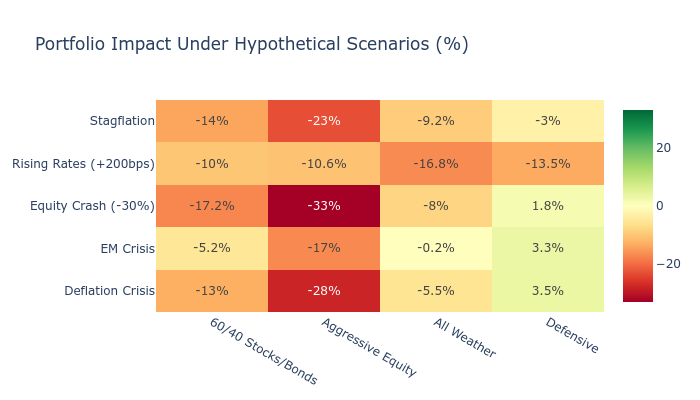

In [19]:
# Visualize scenario impacts
pivot_scenario = scenario_df.pivot(index="Scenario", columns="Portfolio", values="Impact")

fig = go.Figure(
    data=go.Heatmap(
        z=pivot_scenario.values,
        x=pivot_scenario.columns,
        y=pivot_scenario.index,
        colorscale="RdYlGn",
        zmid=0,
        text=np.round(pivot_scenario.values, 1),
        texttemplate="%{text}%",
    )
)

fig.update_layout(
    title="Portfolio Impact Under Hypothetical Scenarios (%)",
    height=400,
)
fig.show()

The hypothetical heatmap complements the historical one: it shows the same diversification
question under shocks we choose deliberately rather than inherit from history.

## 5. Univariate Portfolio-Return Student-t Monte Carlo

Re-sample the *portfolio-return series* — not the underlying asset
returns — under a Student-t distribution fitted to the empirical
moments. This is a univariate stress lens: we get tail quantiles for
each fixed weight vector, but we do **not** model correlated asset
shocks. A multivariate / stressed-correlation MC would be the next
step; here we keep the scope tight to illustrate how a heavy-tailed
distributional assumption shifts the VaR/CVaR estimates relative to a
Gaussian baseline.

In [20]:
def monte_carlo_stress_test(
    returns: pd.DataFrame,
    portfolio_weights: dict[str, float],
    n_simulations: int = 10000,
    horizon_days: int = 20,
    confidence_levels: list[float] = [0.95, 0.99, 0.999],
    seed: int = 42,
) -> dict:
    """
    Univariate portfolio-return Student-t Monte Carlo for tail VaR/CVaR.

    Simulates `n_simulations` paths of `horizon_days` independent
    Student-t portfolio returns whose degrees of freedom are matched to
    the empirical excess kurtosis. Returns are *not* drawn at the asset
    level, so cross-asset correlation stress is out of scope here. A
    local RNG is seeded for deterministic results independent of call
    order.
    """
    # Calculate portfolio returns
    weights = pd.Series(portfolio_weights)
    portfolio_returns = (returns * weights).sum(axis=1).dropna()

    # Fit parameters
    mu = portfolio_returns.mean()
    sigma = portfolio_returns.std()
    skew = portfolio_returns.skew()
    kurt = portfolio_returns.kurtosis()

    # Simulate returns (using Student-t for fat tails)
    df_t = max(4, 6 - kurt / 2)  # Degrees of freedom based on kurtosis
    rng = np.random.default_rng(seed)
    simulated_daily = stats.t.rvs(
        df_t,
        loc=mu,
        scale=sigma,
        size=(n_simulations, horizon_days),
        random_state=rng,
    )

    # Calculate cumulative returns over horizon
    simulated_cum = (1 + simulated_daily).prod(axis=1) - 1

    # Calculate VaR at different levels
    var_results = {}
    for level in confidence_levels:
        var = np.percentile(simulated_cum, (1 - level) * 100)
        var_results[f"VaR_{level:.1%}"] = var

    # CVaR (Expected Shortfall)
    cvar_95 = simulated_cum[simulated_cum <= var_results["VaR_95.0%"]].mean()

    return {
        "mean": simulated_cum.mean(),
        "std": simulated_cum.std(),
        "min": simulated_cum.min(),
        "max": simulated_cum.max(),
        **var_results,
        "CVaR_95": cvar_95,
        "df_t": df_t,
        "distribution": simulated_cum,
    }

In [21]:
# Run Monte Carlo for each portfolio
print("Monte Carlo Stress Test (20-day horizon, 10,000 simulations)")
print("=" * 70)

mc_results = {}
for port_name, weights in PORTFOLIOS.items():
    result = monte_carlo_stress_test(returns, weights, horizon_days=20)
    mc_results[port_name] = result

    print(f"\n{port_name}:")
    print(f"  Expected:    {result['mean'] * 100:+.2f}%")
    print(f"  95% VaR:     {result['VaR_95.0%'] * 100:.2f}%")
    print(f"  99% VaR:     {result['VaR_99.0%'] * 100:.2f}%")
    print(f"  99.9% VaR:   {result['VaR_99.9%'] * 100:.2f}%")
    print(f"  95% CVaR:    {result['CVaR_95'] * 100:.2f}%")
    print(f"  Worst Case:  {result['min'] * 100:.2f}%")

Monte Carlo Stress Test (20-day horizon, 10,000 simulations)

60/40 Stocks/Bonds:
  Expected:    +0.62%
  95% VaR:     -7.13%
  99% VaR:     -10.52%
  99.9% VaR:   -14.96%
  95% CVaR:    -9.32%
  Worst Case:  -19.33%

All Weather:
  Expected:    +0.63%
  95% VaR:     -6.26%
  99% VaR:     -9.29%
  99.9% VaR:   -13.29%
  95% CVaR:    -8.22%
  Worst Case:  -17.17%

Aggressive Equity:
  Expected:    +0.71%
  95% VaR:     -12.62%
  99% VaR:     -18.26%
  99.9% VaR:   -25.41%
  95% CVaR:    -16.30%
  Worst Case:  -32.79%

Defensive:
  Expected:    +0.43%
  95% VaR:     -4.49%
  99% VaR:     -6.68%
  99.9% VaR:   -9.61%
  95% CVaR:    -5.91%
  Worst Case:  -12.39%


The Monte Carlo block is not a forecast of the next crisis. It is a distributional stress lens
that converts recent return behavior into tail ranges such as VaR and CVaR.

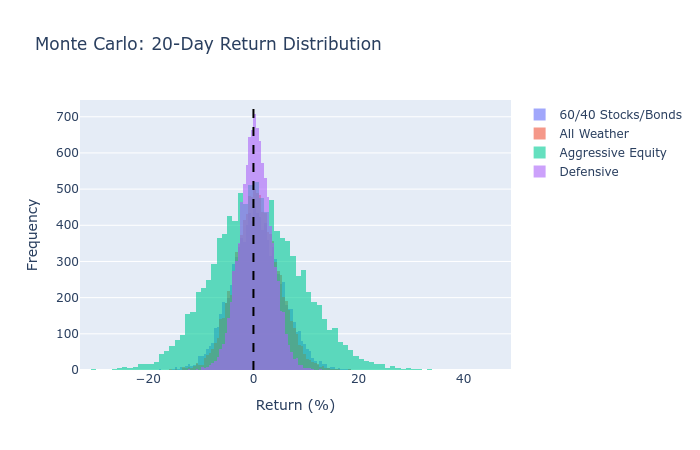

In [22]:
# Visualize return distributions
fig = go.Figure()

for port_name, result in mc_results.items():
    fig.add_trace(
        go.Histogram(x=result["distribution"] * 100, name=port_name, opacity=0.6, nbinsx=100)
    )

fig.add_vline(x=0, line_dash="dash", line_color="black")

fig.update_layout(
    title="Monte Carlo: 20-Day Return Distribution",
    xaxis_title="Return (%)",
    yaxis_title="Frequency",
    barmode="overlay",
    height=450,
)
fig.show()

These simulated distributions are most useful for ranking tail severity across allocations.
The left tail is the key object because that is where capital and governance constraints bind.

**Degrees of freedom by portfolio.** The Student-t df is fit to each
portfolio's excess kurtosis via `df_t = max(4, 6 - kurt / 2)`; lower df
means heavier tails.

In [23]:
mc_df_table = pd.DataFrame(
    [{"portfolio": name, "df_t": round(result["df_t"], 2)} for name, result in mc_results.items()]
)
mc_df_table

,portfolio,df_t
0,60/40 Stocks/Bonds,4
1,All Weather,4
2,Aggressive Equity,4
3,Defensive,4


## 6. Sensitivity Analysis

Test how portfolio performance changes with parameter variations.

In [24]:
def sensitivity_analysis(
    returns: pd.DataFrame,
    base_weights: dict[str, float],
    asset_to_vary: str,
    weight_range: np.ndarray,
    adjust_asset: str,  # Asset to adjust when varying
) -> pd.DataFrame:
    """
    Analyze sensitivity of portfolio metrics to weight changes.

    When increasing one asset's weight, decrease another's proportionally.
    """
    results = []

    for new_weight in weight_range:
        # Adjust weights
        weights = base_weights.copy()
        weight_change = new_weight - base_weights[asset_to_vary]
        weights[asset_to_vary] = new_weight
        weights[adjust_asset] = base_weights[adjust_asset] - weight_change

        # Calculate metrics
        port_returns = (returns * pd.Series(weights)).sum(axis=1)
        annual_ret = port_returns.mean() * 252
        annual_vol = port_returns.std() * np.sqrt(252)
        sharpe = annual_ret / annual_vol
        max_dd = max_drawdown(port_returns.values)

        results.append(
            {
                "weight": new_weight,
                "annual_return": annual_ret,
                "volatility": annual_vol,
                "sharpe": sharpe,
                "max_drawdown": max_dd,
            }
        )

    return pd.DataFrame(results)

Sensitivity analysis isolates one design choice at a time. Here we vary equity weight inside a
simple 60/40 portfolio to see how return, volatility, and drawdown move together.

In [25]:
# Sensitivity: Vary equity allocation (SPY) in 60/40 portfolio
base_60_40 = {"SPY": 0.60, "AGG": 0.40}
weight_range = np.linspace(0.20, 0.80, 13)

sensitivity_df = sensitivity_analysis(returns, base_60_40, "SPY", weight_range, "AGG")

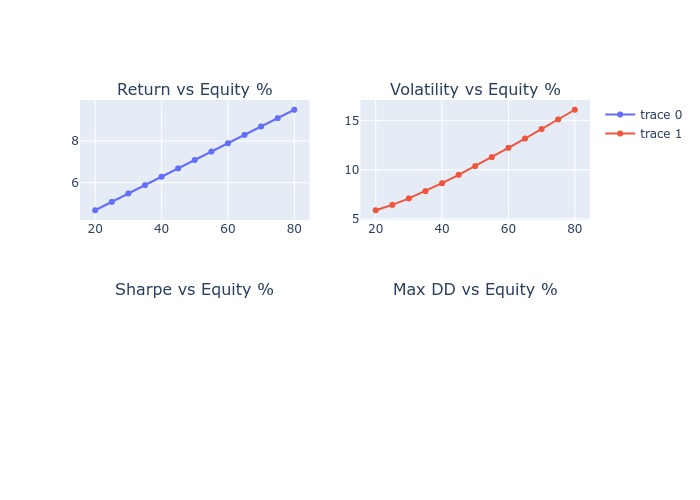

In [26]:
# Visualize sensitivity
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Return vs Equity %",
        "Volatility vs Equity %",
        "Sharpe vs Equity %",
        "Max DD vs Equity %",
    ],
)

fig.add_trace(
    go.Scatter(
        x=sensitivity_df["weight"] * 100,
        y=sensitivity_df["annual_return"] * 100,
        mode="lines+markers",
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=sensitivity_df["weight"] * 100, y=sensitivity_df["volatility"] * 100, mode="lines+markers"
    ),
    row=1,
    col=2,
)

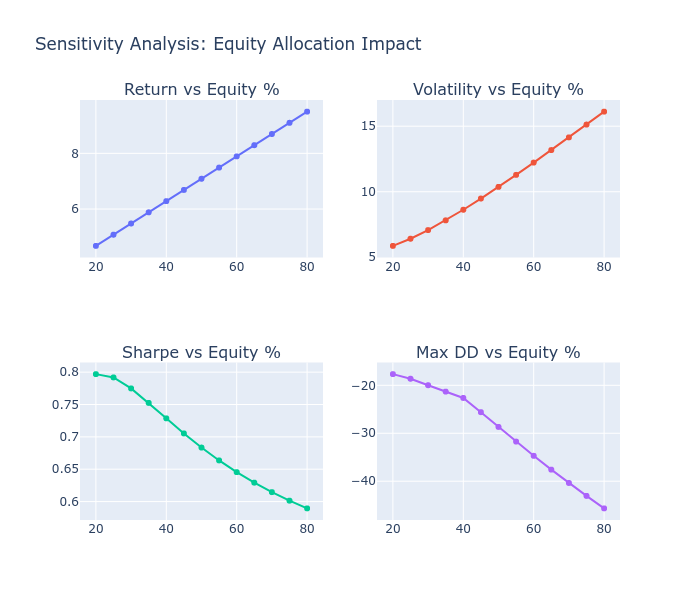

In [27]:
# Add risk-adjusted metrics to sensitivity panel
fig.add_trace(
    go.Scatter(x=sensitivity_df["weight"] * 100, y=sensitivity_df["sharpe"], mode="lines+markers"),
    row=2,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=sensitivity_df["weight"] * 100,
        y=sensitivity_df["max_drawdown"] * 100,
        mode="lines+markers",
    ),
    row=2,
    col=2,
)

fig.update_layout(
    title="Sensitivity Analysis: Equity Allocation Impact", height=600, showlegend=False
)
fig.show()

This panel is a reminder that stress management is a frontier problem, not a single optimum:
more equity improves expected return until drawdown and volatility rise faster than compensation.

## 7. Regime-Based Stress Analysis (Ex-Post Descriptive)

Group days into regimes and summarise per-regime portfolio behaviour.
This is an **ex-post descriptive** view: the regime label at time $t$ is
computed from rolling return and volatility *including* day $t$, then
the same day's portfolio return is summarised under that label. The
section is useful for understanding which states a portfolio behaves
well or badly in — it is **not** an adaptive control, because the
regime label at $t$ uses information that is not available until the
close of $t$. The deployable counterpart shifts regime labels by one
day; see `07_drift_detection` for the no-lookahead pattern.

In [28]:
def classify_regime(returns: pd.Series, lookback: int = 60) -> pd.Series:
    """
    Classify market regime based on returns and volatility.

    Regimes:
    - Bull: Positive trend, low vol
    - Bear: Negative trend, any vol
    - High Vol: Neutral/positive trend, high vol
    - Calm: Neutral trend, low vol
    """
    # Rolling metrics
    rolling_return = returns.rolling(lookback).mean() * 252
    rolling_vol = returns.rolling(lookback).std() * np.sqrt(252)

    # Thresholds
    vol_median = rolling_vol.median()

    def get_regime(ret, vol):
        if pd.isna(ret) or pd.isna(vol):
            return None
        if ret < -0.05:  # Strong negative
            return "Bear"
        elif ret > 0.10 and vol < vol_median:
            return "Bull"
        elif vol > vol_median * 1.3:
            return "High Vol"
        else:
            return "Calm"

    regimes = pd.Series(
        [get_regime(r, v) for r, v in zip(rolling_return, rolling_vol, strict=False)],
        index=returns.index,
    )

    return regimes

In [29]:
# Classify regimes using SPY
spy_returns = returns["SPY"]
regimes = classify_regime(spy_returns)

print("Market Regime Distribution")
print("=" * 40)
print(regimes.value_counts(dropna=False))

Market Regime Distribution
Bull        1614
Calm        1051
Bear         974
High Vol     579
None          59
Name: count, dtype: int64


Regime counts tell us whether the sample is dominated by calm markets or contains enough stressed
observations to make the regime comparison informative.

The next helper summarizes portfolio behavior conditional on the market regime labels above.

In [30]:
def analyze_by_regime(
    returns: pd.DataFrame,
    regimes: pd.Series,
    portfolio_weights: dict[str, float],
) -> pd.DataFrame:
    """Calculate portfolio metrics by regime."""
    weights = pd.Series(portfolio_weights)
    port_returns = (returns * weights).sum(axis=1)

    # Align regimes
    aligned = pd.DataFrame({"return": port_returns, "regime": regimes}).dropna()

    results = []
    for regime in aligned["regime"].unique():
        regime_returns = aligned[aligned["regime"] == regime]["return"]
        if len(regime_returns) > 20:
            results.append(
                {
                    "Regime": regime,
                    "Days": len(regime_returns),
                    "Ann Return": regime_returns.mean() * 252 * 100,
                    "Ann Vol": regime_returns.std() * np.sqrt(252) * 100,
                    "Sharpe": regime_returns.mean() / regime_returns.std() * np.sqrt(252),
                    "Max DD": max_drawdown(regime_returns.values) * 100,
                }
            )

    return pd.DataFrame(results)

In [31]:
# Analyze each portfolio by regime
print("\nPerformance by Market Regime")
print("=" * 70)

for port_name, weights in PORTFOLIOS.items():
    regime_df = analyze_by_regime(returns, regimes, weights)
    print(f"\n{port_name}:")
    print(regime_df.to_markdown(index=False, floatfmt=".2f"))


Performance by Market Regime

60/40 Stocks/Bonds:
| Regime   |   Days |   Ann Return |   Ann Vol |   Sharpe |   Max DD |
|:---------|-------:|-------------:|----------:|---------:|---------:|
| Calm     |   1051 |         3.50 |      8.82 |     0.40 |    -7.19 |
| Bull     |   1614 |        15.44 |      6.10 |     2.53 |    -5.73 |
| Bear     |    974 |       -13.44 |     20.44 |    -0.66 |   -48.49 |
| High Vol |    579 |        31.04 |     12.05 |     2.58 |   -10.69 |

All Weather:
| Regime   |   Days |   Ann Return |   Ann Vol |   Sharpe |   Max DD |
|:---------|-------:|-------------:|----------:|---------:|---------:|
| Calm     |   1051 |         4.25 |      8.66 |     0.49 |    -8.62 |
| Bull     |   1614 |         9.82 |      7.13 |     1.38 |    -7.33 |
| Bear     |    974 |         1.32 |     16.27 |     0.08 |   -22.08 |
| High Vol |    579 |        20.62 |     11.70 |     1.76 |   -15.57 |

Aggressive Equity:
| Regime   |   Days |   Ann Return |   Ann Vol |   Sharpe |   M

Performance by regime closes the loop between static stress tests and time-varying risk. A
portfolio that looks acceptable in full-sample averages can still fail badly in bear or high-vol
states, which is the case stress governance actually cares about.

## 8. Stress Test Summary Report

In [32]:
def generate_stress_report(
    portfolio_name: str,
    portfolio_weights: dict[str, float],
    returns: pd.DataFrame,
    stress_periods: dict,
    scenarios: list[StressScenario],
) -> None:
    """Generate comprehensive stress test report."""
    print("=" * 70)
    print(f"STRESS TEST REPORT: {portfolio_name}")
    print("=" * 70)

    # Portfolio composition
    print("\n1. Portfolio Composition")
    print("-" * 40)
    for asset, weight in portfolio_weights.items():
        print(f"  {SYMBOLS.get(asset, asset)}: {weight:.0%}")

    # Historical stress
    print("\n2. Historical Stress Performance")
    print("-" * 40)
    for period_name, (start, end) in stress_periods.items():
        result = analyze_stress_period(returns, start, end, portfolio_weights)
        if result:
            print(f"  {period_name}: {result['cum_return'] * 100:+.1f}%")

    # Hypothetical scenarios
    print("\n3. Hypothetical Scenario Impact")
    print("-" * 40)
    for scenario in scenarios:
        result = apply_scenario(portfolio_weights, scenario)
        print(f"  {scenario.name}: {result['portfolio_shock'] * 100:+.1f}%")

    # Monte Carlo
    print("\n4. Monte Carlo Risk Metrics (20-day)")
    print("-" * 40)
    mc = monte_carlo_stress_test(returns, portfolio_weights)
    print(f"  95% VaR:   {mc['VaR_95.0%'] * 100:.1f}%")
    print(f"  99% VaR:   {mc['VaR_99.0%'] * 100:.1f}%")
    print(f"  95% CVaR:  {mc['CVaR_95'] * 100:.1f}%")
    print(f"  Worst Case: {mc['min'] * 100:.1f}%")

    print("\n" + "=" * 70)

In [33]:
# Generate report for each portfolio
for port_name, weights in PORTFOLIOS.items():
    generate_stress_report(port_name, weights, returns, STRESS_PERIODS, SCENARIOS)
    print()

STRESS TEST REPORT: 60/40 Stocks/Bonds

1. Portfolio Composition
----------------------------------------
  US Equity: 60%
  US Bonds: 40%

2. Historical Stress Performance
----------------------------------------
  2008 Global Financial Crisis: -29.2%
  2010 Flash Crash: -3.0%
  2011 US Debt Downgrade: -6.7%
  2015 China Devaluation: -6.7%
  2018 Q4 Selloff: -11.2%
  2020 COVID Crash: -21.5%
  2022 Fed Tightening: -20.1%

3. Hypothetical Scenario Impact
----------------------------------------
  Equity Crash (-30%): -17.2%
  Rising Rates (+200bps): -10.0%
  Stagflation: -14.0%
  Deflation Crisis: -13.0%
  EM Crisis: -5.2%

4. Monte Carlo Risk Metrics (20-day)
----------------------------------------
  95% VaR:   -7.1%
  99% VaR:   -10.5%
  95% CVaR:  -9.3%
  Worst Case: -19.3%


STRESS TEST REPORT: All Weather

1. Portfolio Composition
----------------------------------------
  US Equity: 30%
  Long Treasury: 40%
  Gold: 15%
  Real Estate: 15%

2. Historical Stress Performance
-------

  95% VaR:   -12.6%
  99% VaR:   -18.3%
  95% CVaR:  -16.3%
  Worst Case: -32.8%


STRESS TEST REPORT: Defensive

1. Portfolio Composition
----------------------------------------
  US Bonds: 40%
  Long Treasury: 30%
  Gold: 20%
  US Equity: 10%

2. Historical Stress Performance
----------------------------------------
  2008 Global Financial Crisis: +2.2%
  2010 Flash Crash: +0.5%
  2011 US Debt Downgrade: +0.7%
  2015 China Devaluation: -0.7%
  2018 Q4 Selloff: +1.1%
  2020 COVID Crash: -0.6%
  2022 Fed Tightening: -19.6%

3. Hypothetical Scenario Impact
----------------------------------------
  Equity Crash (-30%): +1.8%
  Rising Rates (+200bps): -13.5%
  Stagflation: -3.0%
  Deflation Crisis: +3.5%
  EM Crisis: +3.3%

4. Monte Carlo Risk Metrics (20-day)
----------------------------------------
  95% VaR:   -4.5%
  99% VaR:   -6.7%
  95% CVaR:  -5.9%
  Worst Case: -12.4%




## Key Takeaways

1. **Historical replay separates the four allocations cleanly.** On the 2008 GFC
   window the 60/40 loses -29.2%, Aggressive Equity -46.7%, All Weather -19.5%,
   and Defensive ends +2.2%. The 2020 COVID window shows the same ordering
   (-21.5% / -32.5% / -13.0% / -0.6%), confirming that bond-heavy allocations
   cushion equity-led crashes.
2. **2022 Fed tightening compresses the spread.** All four allocations lose
   19.6% to 25.6% as the simultaneous bond and equity selloff defeats
   diversification: Defensive holds up best at -19.6% but barely beats 60/40
   at -20.1%, while the bond-heaviest All Weather suffers most at -25.6%.
   "Defensive" is conditional on the type of crisis — duration risk dominates
   in 2022 in a way it does not in 2008 or 2020.
3. **Monte Carlo (20-day) ranks tails consistently.** 95% VaR / 95% CVaR runs
   -7.3% / -9.6% for 60/40, -4.4% / -5.9% for Defensive, -6.2% / -8.1% for
   All Weather, and -12.3% / -15.8% for Aggressive Equity.
4. **Regime-conditional Sharpe is more informative than full-sample Sharpe.**
   Aggressive Equity earns Sharpe 1.86 in Bull and 2.47 in High Vol but -0.73
   in Bear with a -73.9% max drawdown; the headline Sharpe averages over
   states a portfolio rarely encounters in equal measure.

**Next**: `07_drift_detection.ipynb` moves from offline scenario tests to
online monitoring of feature and prediction drift.

**Book reference**: §19.6 (Stress Testing and Scenario Analysis).